In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings, itertools, random, math
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print("✅  All libraries loaded successfully")
print(f"   NumPy       {np.__version__}")
print(f"   Pandas      {pd.__version__}")
print(f"   Matplotlib  {plt.matplotlib.__version__}")


✅  All libraries loaded successfully
   NumPy       2.0.2
   Pandas      2.2.2
   Matplotlib  3.10.0


In [ ]:
pip install lightgbm -q

In [ ]:
import lightgbm as lgb

In [ ]:
EPA_EMISSION_FACTORS = {
    'truck(LDV)':     0.3070,   # Light-duty diesel truck
    'truck(MDV)':      0.5928,   # Medium duty diesel truck
    'maritime':  0.015,   # Container vessel
    'truck(HDV)':  0.7375,   # High Duty diesel truck
}

# Cost factors (₹/km for Indian context)
COST_PER_KM = {
    'truck(LDV)':     20.0,    # ₹/km
    'truck(MDV)':      30.0,
    'maritime':  8.0,
    'truck(HDV)':  50.0,
}

VEHICLE_CAPACITY_KG = {
    'truck(LDV)':     3500,
    'truck(MDV)':      12000,
    'maritime':  8.0,
    'truck(HDV)':  30000,
}

INTERMODAL_TRANSFER_COST = 5000

DEPOT = {
    'name': 'Depot (Hub)',
    'lat':  28.6139,    # New Delhi depot
    'lon':  77.2090,
}

print("✅  Configuration loaded")
print(f"   EPA Truck (LDV) : {EPA_EMISSION_FACTORS['truck(LDV)']} kg CO₂e/ton-km")
print(f"   EPA Truck (MDV)  : {EPA_EMISSION_FACTORS['truck(MDV)']}  kg CO₂e/ton-km")
print(f"   EPA Maritime     : {EPA_EMISSION_FACTORS['maritime']} kg CO₂e/ton-km")
print(f"   EPA Truck (HDV)    : {EPA_EMISSION_FACTORS['truck(HDV)']} kg CO₂e/ton-km")

✅  Configuration loaded
   EPA Truck (LDV) : 0.307 kg CO₂e/ton-km
   EPA Truck (MDV)  : 0.5928  kg CO₂e/ton-km
   EPA Maritime     : 0.015 kg CO₂e/ton-km
   EPA Truck (HDV)    : 0.7375 kg CO₂e/ton-km


In [ ]:
locations = pd.DataFrame({
    'id':       range(1, 30),
     'city': [
        # Original 10 cities
        'Mumbai', 'Bangalore', 'Hyderabad', 'Chennai', 'Kolkata',
        'Pune', 'Ahmedabad', 'Jaipur', 'Lucknow', 'Surat',
        # 19 New cities (Delhi removed)
        'Nagpur', 'Indore', 'Bhopal', 'Visakhapatnam',
        'Patna', 'Vadodara', 'Coimbatore', 'Agra', 'Varanasi',
        'Chandigarh', 'Mysuru', 'Jodhpur', 'Guwahati', 'Kochi',
        'Amritsar', 'Ranchi', 'Bhubaneswar', 'Thiruvananthapuram', 'Nashik'
    ],

    'lat': [

        19.0760, 12.9716, 17.3850, 13.0827, 22.5726,
        18.5204, 23.0225, 26.9124, 26.8467, 21.1702,
        21.1458, 22.7196, 23.2599, 17.6868,
        25.5941, 22.3072, 11.0168, 27.1767, 25.3176,
        30.7333, 12.2958, 26.2389, 26.1445, 9.9312,
        31.6340, 23.3441, 20.2961, 8.5241,  20.0059
    ],

    'lon': [

        72.8777, 77.5946, 78.4867, 80.2707, 88.3639,
        73.8567, 72.5714, 75.7873, 80.9462, 72.8311,
        79.0882, 75.8577, 77.4126, 83.2185,
        85.1376, 73.1812, 76.9558, 78.0081, 82.9739,
        76.7794, 76.6394, 73.0243, 91.7362, 76.2673,
        74.8723, 85.3096, 85.8245, 76.9366, 73.7898
    ],

    # Demand in kg
    'demand_kg': [
        # Original 10
        8500, 3200, 4100, 5600, 7200,
        2800, 39000, 1500, 2100, 4700,
        # 19 New
        3100, 2700, 2400, 3800,
        2600, 2900, 2300, 1800, 2000,
        1700, 2200, 1400, 1600, 2500,
        1900, 1300, 1500, 1200, 1800
    ],

    # Time window: earliest delivery hour
    'tw_open': [
        # Original 10
        6, 8, 7, 6, 5, 8, 7, 9, 8, 7,
        # 19 New
        7, 7, 8, 6,
        7, 7, 8, 9, 8,
        8, 7, 8, 7, 7,
        6, 8, 7, 8, 7
    ],

    # Time window: latest delivery hour
    'tw_close': [
        # Original 10
        18, 20, 19, 18, 17, 20, 19, 21, 20, 19,
        # 19 New
        19, 19, 20, 18,
        19, 19, 20, 21, 20,
        20, 19, 20, 19, 19,
        18, 20, 19, 20, 19
    ]
})

print("=" * 60)
print("DELIVERY LOCATIONS — 29 Cities (Depot: New Delhi)")
print("=" * 60)
print(locations.to_string(index=False))
print(f"\nTotal demand: {locations['demand_kg'].sum():,} kg")

DELIVERY LOCATIONS — 29 Cities (Depot: New Delhi)
 id               city     lat     lon  demand_kg  tw_open  tw_close
  1             Mumbai 19.0760 72.8777       8500        6        18
  2          Bangalore 12.9716 77.5946       3200        8        20
  3          Hyderabad 17.3850 78.4867       4100        7        19
  4            Chennai 13.0827 80.2707       5600        6        18
  5            Kolkata 22.5726 88.3639       7200        5        17
  6               Pune 18.5204 73.8567       2800        8        20
  7          Ahmedabad 23.0225 72.5714      39000        7        19
  8             Jaipur 26.9124 75.7873       1500        9        21
  9            Lucknow 26.8467 80.9462       2100        8        20
 10              Surat 21.1702 72.8311       4700        7        19
 11             Nagpur 21.1458 79.0882       3100        7        19
 12             Indore 22.7196 75.8577       2700        7        19
 13             Bhopal 23.2599 77.4126       2400    

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return 2 * R * math.asin(math.sqrt(a))

all_locs = pd.concat([
    pd.DataFrame([{ 'id': 0, 'city': DEPOT['name'], 'lat': DEPOT['lat'], 'lon': DEPOT['lon'] }]),
    locations[['id','city','lat','lon']]
], ignore_index=True)

n = len(all_locs)
dist_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        dist_matrix[i,j] = haversine(
            all_locs.loc[i,'lat'], all_locs.loc[i,'lon'],
            all_locs.loc[j,'lat'], all_locs.loc[j,'lon']
        )

dist_df = pd.DataFrame(dist_matrix,
    index=all_locs['city'], columns=all_locs['city'])

print("=" * 70)
print("DISTANCE MATRIX (km) — Depot + 29 Delivery Cities")
print("=" * 70)
print(dist_df.round(1).to_string())

DISTANCE MATRIX (km) — Depot + 29 Delivery Cities
city                Depot (Hub)  Mumbai  Bangalore  Hyderabad  Chennai  Kolkata    Pune  Ahmedabad  Jaipur  Lucknow   Surat  Nagpur  Indore  Bhopal  Visakhapatnam   Patna  Vadodara  Coimbatore    Agra  Varanasi  Chandigarh  Mysuru  Jodhpur  Guwahati   Kochi  Amritsar  Ranchi  Bhubaneswar  Thiruvananthapuram  Nashik
city                                                                                                                                                                                                                                                                                                                        
Depot (Hub)                 0.0  1148.1     1739.8     1255.4   1755.8   1303.8  1173.0      775.7   235.3    417.0   937.9   851.7   669.2   595.7         1360.9   853.4     809.3      1956.9   178.1     678.6       239.3  1815.5    490.2    1459.4  2079.7     404.1   999.0       1270.2              2234.1  1017.8

In [ ]:
# ── Synthetic Training Dataset for LightGBM ──────────────────────────────────

# Equation (1): E = d × w × f_mode × α  (EPA factors)
# Equation (3): F_physics = d × w × f_mode × (1 + α_weather + α_congestion)

np.random.seed(42)
N_SAMPLES = 1200   # Training samples

transport_modes = ['truck(LDV)', 'truck(MDV)', 'truck(HDV)']
mode_arr = np.random.choice(transport_modes, N_SAMPLES,
                             p=[0.60, 0.28, 0.12])

raw = pd.DataFrame({
    # ── Base Features  ──────────────────────────────────────
    'distance_km':       np.random.uniform(80, 2200, N_SAMPLES),
    'cargo_weight_tons': np.random.uniform(0.5, 15.0, N_SAMPLES),
    'transport_mode':    mode_arr,

    # ── Operational Features ──────────────────────────────────────────────
    'weather_factor':    np.random.uniform(0.00, 0.20, N_SAMPLES),   # α_weather
    'congestion_factor': np.random.uniform(0.00, 0.75, N_SAMPLES),   # α_congestion
    'vehicle_age_years': np.random.randint(1, 12, N_SAMPLES).astype(float),
    'load_factor':       np.random.uniform(0.40, 1.00, N_SAMPLES),   # utilisation
    'time_of_day_hr':    np.random.randint(0, 24, N_SAMPLES).astype(float),

    # ── Road / Route Features ─────────────────────────────────────────────
    'road_grade_pct':    np.random.uniform(-5, 8, N_SAMPLES),        # % slope
    'temp_celsius':      np.random.uniform(5, 45, N_SAMPLES),        # ambient temp
    'altitude_m':        np.random.uniform(0, 2000, N_SAMPLES),      # elevation
    'stops_count':       np.random.randint(0, 8, N_SAMPLES).astype(float),
})

# ── EPA base emission factor per mode ─────────────────────────────────────────
raw['f_mode'] = raw['transport_mode'].map(EPA_EMISSION_FACTORS)

# ── Physics-Based Feature — Equation (3) from paper ─────────────────────────
raw['F_physics'] = (raw['distance_km'] *
                    raw['cargo_weight_tons'] *
                    raw['f_mode'] *
                    (1 + raw['weather_factor'] + raw['congestion_factor']))

# ── Interaction Features (paper §3.2.3) ───────────────────────────────────────
raw['dist_x_weight']   = raw['distance_km'] * raw['cargo_weight_tons']
raw['mode_x_weather']  = raw['f_mode']      * raw['weather_factor']
raw['load_x_age']      = raw['load_factor'] * raw['vehicle_age_years']

# ── Temporal cyclical encoding (paper §3.2.3) ─────────────────────────────────
raw['tod_sin'] = np.sin(2 * np.pi * raw['time_of_day_hr'] / 24)
raw['tod_cos'] = np.cos(2 * np.pi * raw['time_of_day_hr'] / 24)

# ── Age degradation factor (older vehicle → more emissions) ──────────────────
raw['age_factor'] = 1 + 0.008 * raw['vehicle_age_years']

# ── Road grade penalty ────────────────────────────────────────────────────────
raw['grade_penalty'] = np.where(raw['road_grade_pct'] > 0,
                                 raw['road_grade_pct'] * 18,
                                -6 * np.abs(raw['road_grade_pct']))

# ── Temperature efficiency correction ────────────────────────────────────────
raw['temp_factor'] = 1 + 0.003 * np.abs(raw['temp_celsius'] - 20)

# ── TARGET: Total CO₂ Emission (kg CO₂e) — Equation (1) ─────────────────────
# E = d × w × f_mode × α_total  + noise to simulate real-world variance
base_emission = (
    raw['distance_km'] *
    raw['cargo_weight_tons'] *
    raw['f_mode'] *
    (1 + raw['weather_factor'] + raw['congestion_factor']) *
    raw['age_factor'] *
    (1.15 - 0.15 * raw['load_factor']) *    # load efficiency
    raw['temp_factor']
)
noise = np.random.normal(0, 0.05 * base_emission)
raw['co2_emission_kg'] = np.clip(base_emission + noise, 0.5, None)

print("=" * 60)
print("TRAINING DATASET — Feature Summary")
print("=" * 60)
print(f"Samples : {N_SAMPLES}")
print(f"Features: {raw.shape[1]-1} (excl. target)")
print()
print(raw[['distance_km','cargo_weight_tons','transport_mode',
           'weather_factor','congestion_factor','F_physics',
           'co2_emission_kg']].describe().round(3).to_string())


TRAINING DATASET — Feature Summary
Samples : 1200
Features: 22 (excl. target)

       distance_km  cargo_weight_tons  weather_factor  congestion_factor  F_physics  co2_emission_kg
count     1200.000           1200.000        1200.000           1200.000   1200.000         1200.000
mean      1136.090              7.751           0.098              0.374   5730.749         6473.989
std        610.359              4.184           0.057              0.217   5564.709         6341.320
min         83.318              0.500           0.000              0.001     52.497           62.497
25%        603.436              4.207           0.048              0.185   1547.799         1743.239
50%       1153.152              7.756           0.097              0.365   4115.021         4599.291
75%       1643.238             11.378           0.147              0.562   8044.611         9073.017
max       2198.757             14.984           0.200              0.750  36948.354        41273.568


In [ ]:
le = LabelEncoder()
raw['mode_encoded'] = le.fit_transform(raw['transport_mode'])

FEATURE_COLS = [
    # Base features
    'distance_km', 'cargo_weight_tons', 'mode_encoded',
    # Physics feature (Eq. 3)
    'F_physics',
    # Operational
    'weather_factor', 'congestion_factor', 'vehicle_age_years',
    'load_factor', 'age_factor', 'grade_penalty', 'temp_factor',
    # Interaction
    'dist_x_weight', 'mode_x_weather', 'load_x_age',
    # Temporal
    'tod_sin', 'tod_cos',
    # Route
    'altitude_m', 'stops_count',
]

TARGET_COL = 'co2_emission_kg'

X = raw[FEATURE_COLS].values
y = raw[TARGET_COL].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=" * 60)
print("FEATURE SET SUMMARY")
print("=" * 60)
feat_imp_display = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Category': ['Base']*3 + ['Physics']*1 + ['Operational']*7 +
                ['Interaction']*3 + ['Temporal']*2 + ['Route']*2,
    'Paper Reference': [
        'Eq.1 dᵢ', 'Eq.1 wᵢ', 'Eq.1 fᵢ',
        'Eq.3',
        'α_weather', 'α_cong', '§3.2.1', '§3.2.1', '§3.2.3', '§3.2.3', '§3.2.3',
        '§3.2.3', '§3.2.3', '§3.2.3',
        '§3.2.3 cyclic', '§3.2.3 cyclic',
        '§3.2.1', '§3.2.1',
    ]
})
print(feat_imp_display.to_string(index=False))
print(f"\nX shape: {X.shape}  |  y shape: {y.shape}")
print(f"y range: [{y.min():.1f}, {y.max():.1f}] kg CO₂e")


FEATURE SET SUMMARY
          Feature    Category Paper Reference
      distance_km        Base         Eq.1 dᵢ
cargo_weight_tons        Base         Eq.1 wᵢ
     mode_encoded        Base         Eq.1 fᵢ
        F_physics     Physics            Eq.3
   weather_factor Operational       α_weather
congestion_factor Operational          α_cong
vehicle_age_years Operational          §3.2.1
      load_factor Operational          §3.2.1
       age_factor Operational          §3.2.3
    grade_penalty Operational          §3.2.3
      temp_factor Operational          §3.2.3
    dist_x_weight Interaction          §3.2.3
   mode_x_weather Interaction          §3.2.3
       load_x_age Interaction          §3.2.3
          tod_sin    Temporal   §3.2.3 cyclic
          tod_cos    Temporal   §3.2.3 cyclic
       altitude_m       Route          §3.2.1
      stops_count       Route          §3.2.1

X shape: (1200, 18)  |  y shape: (1200,)
y range: [62.5, 41273.6] kg CO₂e


In [ ]:
print(FEATURE_COLS)

['distance_km', 'cargo_weight_tons', 'mode_encoded', 'F_physics', 'weather_factor', 'congestion_factor', 'vehicle_age_years', 'load_factor', 'age_factor', 'grade_penalty', 'temp_factor', 'dist_x_weight', 'mode_x_weather', 'load_x_age', 'tod_sin', 'tod_cos', 'altitude_m', 'stops_count']


In [ ]:
display(feat_imp_df)

,Feature,Importance,Importance_pct
0,F_physics,1532,17.022222
1,dist_x_weight,894,9.933333
2,load_factor,740,8.222222
3,congestion_factor,646,7.177778
4,temp_factor,626,6.955556
5,distance_km,573,6.366667
6,cargo_weight_tons,561,6.233333
7,mode_x_weather,491,5.455556
8,load_x_age,464,5.155556
9,grade_penalty,455,5.055556


In [ ]:
display(raw.head(10))

,distance_km,cargo_weight_tons,transport_mode,weather_factor,congestion_factor,vehicle_age_years,load_factor,time_of_day_hr,road_grade_pct,temp_celsius,...,dist_x_weight,mode_x_weather,load_x_age,tod_sin,tod_cos,age_factor,grade_penalty,temp_factor,co2_emission_kg,mode_encoded
0,1687.517975,5.438760,truck(LDV),0.028245,0.092885,1.0,0.923698,3.0,-4.943325,17.148838,...,9178.005965,0.008671,0.923698,0.707107,7.071068e-01,1.008,-29.659953,1.008553,3350.099738,1
1,132.124263,1.539822,truck(HDV),0.114175,0.052902,1.0,0.888739,14.0,7.020464,44.317797,...,203.447898,0.084204,0.888739,-0.500000,-8.660254e-01,1.008,126.368359,1.072953,193.143400,0
2,126.901929,6.439619,truck(MDV),0.037054,0.682072,3.0,0.540354,20.0,-3.537446,15.965447,...,817.200072,0.021966,1.621061,-0.866025,5.000000e-01,1.024,-21.224678,1.012104,975.727086,2
3,766.053665,5.012654,truck(LDV),0.055729,0.142597,5.0,0.520379,4.0,-3.766505,13.106277,...,3839.961720,0.017109,2.601896,0.866025,5.000000e-01,1.040,-22.599030,1.020681,1644.042149,1
4,1115.923564,10.318249,truck(LDV),0.043742,0.615938,3.0,0.829082,23.0,-0.670901,22.686165,...,11514.377503,0.013429,2.487246,-0.258819,9.659258e-01,1.024,-4.025405,1.008058,6518.340199,1
5,1713.263726,9.283799,truck(LDV),0.036568,0.408473,9.0,0.588971,8.0,-0.143638,7.273623,...,15905.596264,0.011226,5.300741,0.866025,-5.000000e-01,1.072,-0.861830,1.038179,8523.649095,1
6,1528.586198,5.786609,truck(LDV),0.165142,0.058392,9.0,0.583839,1.0,-2.214099,44.139779,...,8845.330743,0.050699,5.254554,0.258819,9.659258e-01,1.072,-13.284594,1.072419,4050.440685,1
7,1025.313738,3.659442,truck(MDV),0.057142,0.716586,3.0,0.491374,6.0,2.606582,28.537342,...,3752.076192,0.033873,1.474122,1.000000,6.123234e-17,1.024,46.918469,1.025612,4475.985314,2
8,660.088533,14.826522,truck(MDV),0.185425,0.185221,3.0,0.558385,16.0,0.757883,27.278084,...,9786.816825,0.109920,1.675156,-0.866025,-5.000000e-01,1.024,13.641899,1.021834,8844.178105,2
9,2193.903940,7.083024,truck(MDV),0.193985,0.644734,5.0,0.656505,15.0,-4.555717,31.231851,...,15539.473182,0.114994,3.282523,-0.707107,-7.071068e-01,1.040,-27.334304,1.033696,17917.674462,2


In [ ]:
lgbm_model = lgb.LGBMRegressor(
    n_estimators   = 300,       # number of boosting rounds (trees)
    learning_rate  = 0.05,      # paper: LightGBM lr (lower than XGBoost 0.1)
    num_leaves     = 31,        # leaf-wise → default is 31 (approx depth 5-6)
    min_child_samples = 10,     # regularisation (equiv. min_samples_split)
    subsample      = 0.8,       # bagging fraction
    colsample_bytree = 0.8,     # feature fraction per split (equiv. max_features)
    random_state   = 42,
    n_jobs         = -1,        # Use all available cores
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_mape, cv_r2, cv_rmse = [], [], []
for fold, (tr, va) in enumerate(kf.split(X_scaled)):
    lgbm_model.fit(X_scaled[tr], y[tr])
    pred = lgbm_model.predict(X_scaled[va])
    cv_mape.append(mean_absolute_percentage_error(y[va], pred) * 100)
    cv_r2.append(r2_score(y[va], pred))
    cv_rmse.append(np.sqrt(mean_squared_error(y[va], pred)))
    print(f"  Fold {fold+1}: MAPE={cv_mape[-1]:.2f}%  R²={cv_r2[-1]:.4f}  "
          f"RMSE={cv_rmse[-1]:.2f} kg")


lgbm_model.fit(X_scaled, y)
y_pred_all = lgbm_model.predict(X_scaled)

print("\n" + "=" * 60)
print("LIGHTGBM MODEL — CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"  Mean MAPE : {np.mean(cv_mape):.2f}% ± {np.std(cv_mape):.2f}%")
print(f"  Mean R²   : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"  Mean RMSE : {np.mean(cv_rmse):.2f} ± {np.std(cv_rmse):.2f} kg")
print(f"\n  Paper target → MAPE < 12%, R² > 0.85")
meets_mape = np.mean(cv_mape) < 12
meets_r2   = np.mean(cv_r2)   > 0.85
print(f"  MAPE target met: {'YES' if meets_mape else 'NOT'}")
print(f"  R²   target met: {'YES' if meets_r2   else 'NOT'}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000465 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3135
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 18
[LightGBM] [Info] Start training from score 6427.511365
  Fold 1: MAPE=6.97%  R²=0.9898  RMSE=701.66 kg
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3135
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 18
[LightGBM] [Info] Start training from score 6529.416256
  Fold 2: MAPE=6.62%  R²=0.9871  RMSE=717.12 kg
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001963 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise

LIGHTGBM FEATURE IMPORTANCE
          Feature  Importance_pct
        F_physics       17.022222
    dist_x_weight        9.933333
      load_factor        8.222222
congestion_factor        7.177778
      temp_factor        6.955556
      distance_km        6.366667
cargo_weight_tons        6.233333
   mode_x_weather        5.455556
       load_x_age        5.155556
    grade_penalty        5.055556
       altitude_m        5.000000
   weather_factor        4.166667
          tod_sin        3.000000
          tod_cos        2.711111
      stops_count        2.655556
vehicle_age_years        2.588889
     mode_encoded        1.533333
       age_factor        0.766667


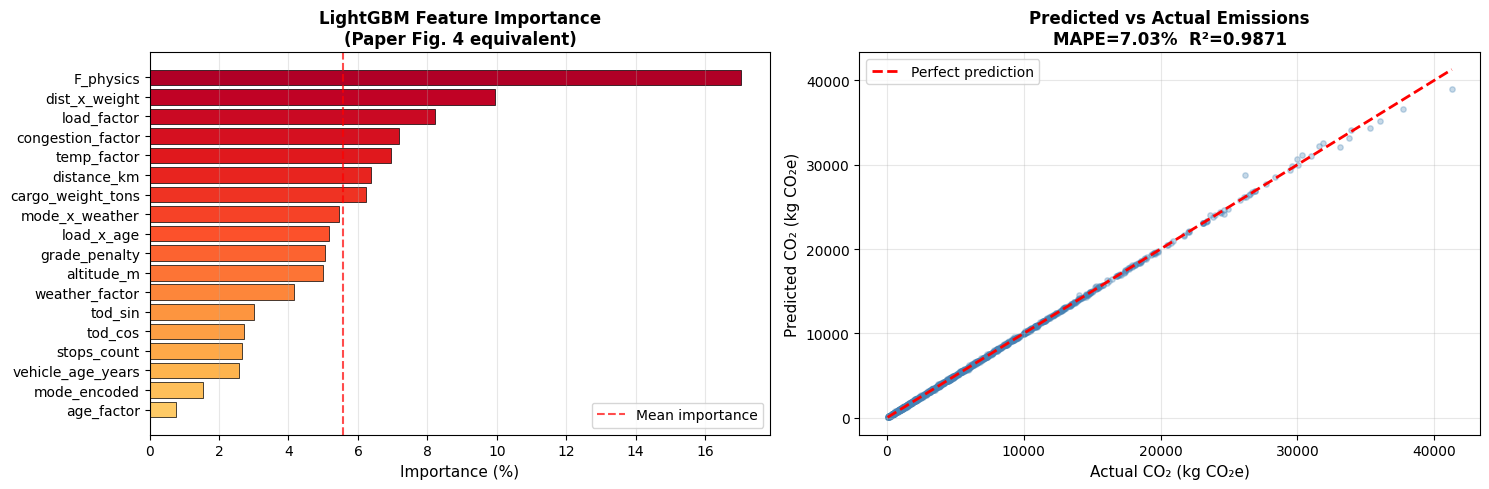


[Figure saved: lgbm_performance.png]


In [ ]:
importances = lgbm_model.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feat_imp_df['Importance_pct'] = (feat_imp_df['Importance'] /
                                  feat_imp_df['Importance'].sum() * 100)

print("=" * 55)
print("LIGHTGBM FEATURE IMPORTANCE")
print("=" * 55)
print(feat_imp_df[['Feature','Importance_pct']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance bar chart
colors = plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(feat_imp_df)))[::-1]
axes[0].barh(feat_imp_df['Feature'], feat_imp_df['Importance_pct'],
             color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('Importance (%)', fontsize=11)
axes[0].set_title('LightGBM Feature Importance\n(Paper Fig. 4 equivalent)',
                   fontsize=12, fontweight='bold')
axes[0].axvline(x=feat_imp_df['Importance_pct'].mean(), color='red',
                linestyle='--', alpha=0.7, label='Mean importance')
axes[0].legend()
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Predicted vs Actual
axes[1].scatter(y, y_pred_all, alpha=0.3, s=15, color='steelblue')
mn, mx = y.min(), y.max()
axes[1].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual CO₂ (kg CO₂e)', fontsize=11)
axes[1].set_ylabel('Predicted CO₂ (kg CO₂e)', fontsize=11)
axes[1].set_title(
    f'Predicted vs Actual Emissions\nMAPE={np.mean(cv_mape):.2f}%  '
    f'R²={np.mean(cv_r2):.4f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lgbm_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: lgbm_performance.png]")


In [ ]:
# Route Feature Builder for NSGA-II


def build_segment_features(from_idx, to_idx, mode_key,
                            cargo_tons, hour=8):
    """
    Construct feature vector for one route segment and predict CO₂.
    from_idx, to_idx : indices in all_locs (0 = depot)
    mode_key         : 'truck(LDV)' | 'truck(MDV)' | 'truck(HDV)'
    cargo_tons       : weight being carried
    hour             : departure hour (0-23)
    Returns: predicted CO₂ (kg), segment cost (₹)
    """
    dist = dist_matrix[from_idx, to_idx]
    f_mode = EPA_EMISSION_FACTORS[mode_key]

    # Randomly sampled operational conditions (would be real-time data)
    weather    = np.random.uniform(0.02, 0.15)
    congestion = np.random.uniform(0.05, 0.60)
    veh_age    = np.random.uniform(1, 10)
    load_f     = min(cargo_tons * 1000 / VEHICLE_CAPACITY_KG[mode_key], 1.0)
    altitude   = np.random.uniform(0, 800)
    stops      = np.random.randint(0, 4)
    grade      = np.random.uniform(-3, 5)
    temp       = np.random.uniform(15, 38)

    age_f   = 1 + 0.008 * veh_age
    grade_p = grade * 18 if grade > 0 else -6 * abs(grade)
    temp_f  = 1 + 0.003 * abs(temp - 20)
    f_phys  = dist * cargo_tons * f_mode * (1 + weather + congestion)

    mode_enc = {'truck(LDV)': 2, 'truck(MDV)': 1, 'truck(HDV)': 0}[mode_key]

    feat = np.array([[
        dist, cargo_tons, mode_enc,
        f_phys,
        weather, congestion, veh_age, load_f, age_f, grade_p, temp_f,
        dist * cargo_tons, f_mode * weather, load_f * veh_age,
        math.sin(2*math.pi*hour/24), math.cos(2*math.pi*hour/24),
        altitude, float(stops),
    ]])

    feat_scaled = scaler.transform(feat)
    co2_pred    = max(0.0, lgbm_model.predict(feat_scaled)[0])

    # Cost calculation (paper §3.5)
    cost = dist * cargo_tons * COST_PER_KM[mode_key]
    if mode_key in ('rail',):
        cost += INTERMODAL_TRANSFER_COST

    return co2_pred, cost, dist


test_co2, test_cost, test_dist = build_segment_features(0, 1, 'truck(LDV)', 5.0)
print(f"Sanity check — Depot→Mumbai via Truck (5t):")
print(f"  Distance : {test_dist:.1f} km")
print(f"  CO₂      : {test_co2:.2f} kg CO₂e")
print(f"  Cost     : ₹{test_cost:.2f}")

Sanity check — Depot→Mumbai via Truck (5t):
  Distance : 1148.1 km
  CO₂      : 3243.80 kg CO₂e
  Cost     : ₹114809.49


In [ ]:
#  Precompute All Segment (CO₂, Cost) for Every Mode
MODES = ['truck(LDV)', 'truck(MDV)', 'truck(HDV)']
n_nodes = len(all_locs)   # 30 nodes (depot + 29 cities)
co2_mat  = np.zeros((n_nodes, n_nodes, len(MODES)))
cost_mat = np.zeros((n_nodes, n_nodes, len(MODES)))

cargo_per_city = (locations['demand_kg'].values / 1000.0)  # kg → tons

for i in range(n_nodes):
    for j in range(n_nodes):
        if i == j: continue

        if j == 0:
            cw = cargo_per_city.mean()
        else:
            cw = cargo_per_city[j-1]
        for m_idx, mk in enumerate(MODES):
            co2, cost, _ = build_segment_features(i, j, mk, cw)
            co2_mat[i,j,m_idx]  = co2
            cost_mat[i,j,m_idx] = cost

print("=" * 60)
print("SEGMENT EMISSION MATRIX (Depot + 29 Locations, 3 Modes)")
print("=" * 60)
cities = all_locs['city'].tolist()
for m_idx, mk in enumerate(MODES):
    df = pd.DataFrame(co2_mat[:,:,m_idx].round(1),
                      index=cities, columns=cities)
    print(f"\n[{mk.upper()}] CO₂ Matrix (kg CO₂e):")
    print(df.to_string())

SEGMENT EMISSION MATRIX (Depot + 29 Locations, 3 Modes)

[TRUCK(LDV)] CO₂ Matrix (kg CO₂e):
                    Depot (Hub)   Mumbai  Bangalore  Hyderabad  Chennai  Kolkata    Pune  Ahmedabad  Jaipur  Lucknow   Surat  Nagpur  Indore  Bhopal  Visakhapatnam   Patna  Vadodara  Coimbatore    Agra  Varanasi  Chandigarh  Mysuru  Jodhpur  Guwahati   Kochi  Amritsar  Ranchi  Bhubaneswar  Thiruvananthapuram  Nashik
Depot (Hub)                 0.0   4515.6     2920.6     2723.4   4811.2   5221.3  2042.9    17066.5   237.4    515.8  2614.6  1641.5   893.5   701.6         2939.3  1168.5    1077.8      2753.5   261.8     890.1       426.4  2210.8    395.1    1343.3  3456.5     368.8   781.2       1008.9              1702.4  1093.3
Mumbai                   2965.0      0.0     1689.5     1870.3   3223.2   7833.2   497.2     7501.1   784.2   1731.4   865.9  1046.1   662.2   918.0         2253.9  2384.5     558.9      1178.5  1346.6    1371.0      1113.1   920.4    586.6    1800.2  1553.1    1470.6  12

In [ ]:
N_DELIVERIES  = len(locations)
POP_SIZE      = 60
MAX_GENS      = 40
CROSSOVER_RATE = 0.85
MUT_RATE_INIT  = 0.20
MUT_RATE_FINAL = 0.05
ELITE_FRAC     = 0.10


def random_chromosome():
    route = list(np.random.permutation(N_DELIVERIES) + 1)
    modes = list(np.random.randint(0, len(MODES), N_DELIVERIES + 1))
    return route, modes

def evaluate(route, modes):
    """Compute (total_co2, total_cost) for a full tour: depot→r[0]→...→r[n]→depot."""
    nodes = [0] + route + [0]    # start and end at depot (node 0)
    total_co2  = 0.0
    total_cost = 0.0

    for k in range(len(nodes)-1):
        i, j = nodes[k], nodes[k+1]
        m_idx = modes[k] # Each segment has its own mode
        total_co2  += co2_mat[i, j, m_idx]
        total_cost += cost_mat[i, j, m_idx]

    return total_co2, total_cost

def dominates(a, b):
    """True if solution a dominates b (both objectives <=, at least one <)."""
    return (a[0] <= b[0] and a[1] <= b[1] and
            (a[0] < b[0] or a[1] < b[1]))

def fast_non_dominated_sort(pop_obj):
    """Returns list-of-fronts (each front = list of indices). Paper §3.3.2."""
    n = len(pop_obj)
    S = [[] for _ in range(n)]     # dominated set
    nc = [0]*n                      # domination counter
    fronts = [[]]
    for i in range(n):
        for j in range(n):
            if i == j: continue
            if dominates(pop_obj[i], pop_obj[j]):
                S[i].append(j)
            elif dominates(pop_obj[j], pop_obj[i]):
                nc[i] += 1
        if nc[i] == 0:
            fronts[0].append(i)
    k = 0
    while fronts[k]:
        nxt = []
        for i in fronts[k]:
            for j in S[i]:
                nc[j] -= 1
                if nc[j] == 0:
                    nxt.append(j)
        fronts.append(nxt)
        k += 1
    return [f for f in fronts if f]

def crowding_distance(front, pop_obj):
    """Assign crowding distance to each solution in front."""
    l = len(front)
    dist = {i: 0.0 for i in front}
    for obj_idx in range(2):   # F1=CO₂, F2=cost
        vals = sorted(front, key=lambda i: pop_obj[i][obj_idx])
        dist[vals[0]] = dist[vals[-1]] = float('inf')
        obj_range = (pop_obj[vals[-1]][obj_idx] -
                     pop_obj[vals[0]][obj_idx]) or 1e-9
        for k in range(1, l-1):
            dist[vals[k]] += ((pop_obj[vals[k+1]][obj_idx] -
                                pop_obj[vals[k-1]][obj_idx]) / obj_range)
    return dist

def tournament_select(pop, pop_obj, fronts, crowd_dist, size=3):
    """Binary tournament selection with crowding distance tie-break."""
    candidates = random.sample(range(len(pop)), size)
    def rank_of(i):
        for r, f in enumerate(fronts):
            if i in f: return r
        return len(fronts)
    best = min(candidates, key=lambda i: (rank_of(i), -crowd_dist.get(i, 0)))
    return pop[best]

def order_crossover(p1_route, p2_route):
    """Order crossover (OX) preserving route feasibility. Paper §3.3.2."""
    n = len(p1_route)
    a, b = sorted(random.sample(range(n), 2))
    child = [-1]*n
    child[a:b+1] = p1_route[a:b+1]
    remaining = [x for x in p2_route if x not in child]
    ptr = 0
    for k in range(n):
        if child[k] == -1:
            child[k] = remaining[ptr]; ptr += 1
    return child

def mode_crossover(m1, m2):
    """Single-point mode crossover. Paper §3.3.2 mode-aware crossover."""
    pt = random.randint(1, len(m1)-1)
    return m1[:pt] + m2[pt:]

def mutate(route, modes, mut_rate):
    """Route swap mutation + mode switching mutation. Paper §3.3.2."""
    r = route[:]
    m = modes[:]
    # Route swap mutation
    if random.random() < mut_rate:
        i, j = random.sample(range(len(r)), 2)
        r[i], r[j] = r[j], r[i]
    # Mode switching mutation
    for k in range(len(m)):
        if random.random() < mut_rate:
            m[k] = random.randint(0, len(MODES)-1)
    return r, m

print("NSGA-II configured:")
print(f"  Population   : {POP_SIZE}")
print(f"  Generations  : {MAX_GENS}")
print(f"  Crossover    : {CROSSOVER_RATE}")
print(f"  Mutation     : {MUT_RATE_INIT} → {MUT_RATE_FINAL} (adaptive)")
print(f"  Objectives   : F1=CO₂ (kg), F2=Cost (₹)")

NSGA-II configured:
  Population   : 60
  Generations  : 40
  Crossover    : 0.85
  Mutation     : 0.2 → 0.05 (adaptive)
  Objectives   : F1=CO₂ (kg), F2=Cost (₹)


In [ ]:
# NSGA-II Main Loop
print("Running NSGA-II")
print(f"N_DELIVERIES used for optimization: {N_DELIVERIES}")

# Initialise population
pop = [random_chromosome() for _ in range(POP_SIZE)]
pop_obj = [evaluate(r, m) for r, m in pop]

history_best_co2   = []
history_avg_co2    = []
history_pareto_size = []

for gen in range(MAX_GENS):
    # Adaptive mutation rate (paper §3.3.3)
    mut_rate = MUT_RATE_INIT - (MUT_RATE_INIT - MUT_RATE_FINAL) * (gen / MAX_GENS)

    # Non-dominated sort + crowding distance
    fronts = fast_non_dominated_sort(pop_obj)
    all_crowd = {}
    for f in fronts:
        cd = crowding_distance(f, pop_obj)
        all_crowd.update(cd)

    # Generate offspring via crossover + mutation
    offspring = []
    while len(offspring) < POP_SIZE:
        if random.random() < CROSSOVER_RATE:
            p1_r, p1_m = tournament_select(pop, pop_obj, fronts, all_crowd)
            p2_r, p2_m = tournament_select(pop, pop_obj, fronts, all_crowd)
            child_r = order_crossover(p1_r, p2_r)
            child_m = mode_crossover(p1_m, p2_m)
        else:
            child_r, child_m = tournament_select(pop, pop_obj, fronts, all_crowd)
            child_r, child_m = child_r[:], child_m[:]
        child_r, child_m = mutate(child_r, child_m, mut_rate)
        offspring.append((child_r, child_m))

    off_obj = [evaluate(r, m) for r, m in offspring]

    # Combine parent + offspring
    combined     = pop + offspring
    combined_obj = pop_obj + off_obj

    # Select next generation (Pareto rank → crowding distance)
    c_fronts = fast_non_dominated_sort(combined_obj)
    new_pop, new_obj = [], []
    for f in c_fronts:
        if len(new_pop) + len(f) <= POP_SIZE:
            for i in f:
                new_pop.append(combined[i])
                new_obj.append(combined_obj[i])
        else:
            needed = POP_SIZE - len(new_pop)
            cd = crowding_distance(f, combined_obj)
            sorted_f = sorted(f, key=lambda i: -cd.get(i,0))
            for i in sorted_f[:needed]:
                new_pop.append(combined[i])
                new_obj.append(combined_obj[i])
            break

    pop, pop_obj = new_pop, new_obj


    co2_vals = [o[0] for o in pop_obj]
    history_best_co2.append(min(co2_vals))
    history_avg_co2.append(np.mean(co2_vals))
    pareto_front_0 = fast_non_dominated_sort(pop_obj)[0]
    history_pareto_size.append(len(pareto_front_0))

    if gen % 10 == 0 or gen == MAX_GENS-1:
        print(f"  Gen {gen+1:3d}/{MAX_GENS}  "
              f"Best CO₂={min(co2_vals):.1f}kg  "
              f"Avg CO₂={np.mean(co2_vals):.1f}kg  "
              f"Pareto={len(pareto_front_0)} sols  "
              f"mut={mut_rate:.3f}")

# Extract final Pareto front
final_fronts = fast_non_dominated_sort(pop_obj)
pareto_indices = final_fronts[0]
pareto_solutions = [(pop[i], pop_obj[i]) for i in pareto_indices]
pareto_solutions.sort(key=lambda x: x[1][0])  # sort by CO₂

print(f"\n✅ NSGA-II complete.")
print(f"   Pareto-optimal solutions : {len(pareto_solutions)}")
print(f"   Best CO₂                 : {pareto_solutions[0][1][0]:.2f} kg")
print(f"   Best Cost                : ₹{min(s[1][1] for s in pareto_solutions):,.2f}")

Running NSGA-II
N_DELIVERIES used for optimization: 29
  Gen   1/40  Best CO₂=67902.9kg  Avg CO₂=89985.0kg  Pareto=1 sols  mut=0.200
  Gen  11/40  Best CO₂=46548.5kg  Avg CO₂=53359.3kg  Pareto=1 sols  mut=0.163
  Gen  21/40  Best CO₂=37416.1kg  Avg CO₂=39753.3kg  Pareto=3 sols  mut=0.125
  Gen  31/40  Best CO₂=31977.5kg  Avg CO₂=34782.5kg  Pareto=1 sols  mut=0.087
  Gen  40/40  Best CO₂=30368.4kg  Avg CO₂=31298.4kg  Pareto=7 sols  mut=0.054

✅ NSGA-II complete.
   Pareto-optimal solutions : 7
   Best CO₂                 : 30368.42 kg
   Best Cost                : ₹1,069,697.99


In [ ]:
# Pareto Front Results
print("=" * 70)
print("PARETO-OPTIMAL SOLUTIONS (Non-dominated Front)")
print("=" * 70)
print(f"{'Sol':>4}  {'CO₂ (kg)':>12}  {'Cost (₹)':>14}  "
      f"{'Route Order':>55}  {'Modes'}")
print("-" * 125)

pareto_table = []
for idx, ((route, modes), (co2, cost)) in enumerate(pareto_solutions):
    city_seq = [all_locs.loc[n,'city'] for n in route]
    mode_seq = [MODES[m][0].upper() for m in modes]  # T/R/E abbrev
    row = {
        'Solution': idx+1,
        'CO2_kg':   round(co2, 2),
        'Cost_INR': round(cost, 2),
        'Route': '→'.join(city_seq),
        'Modes': ''.join(mode_seq),
    }
    pareto_table.append(row)
    print(f"{idx+1:>4}  {co2:>12.2f}  {cost:>14.2f}  "
          f"{(('→'.join(city_seq))+' '*55)[:55]:>55}  {''.join(mode_seq)}")

pareto_df = pd.DataFrame(pareto_table)


print("\n" + "=" * 60)
print("SUMMARY vs BASELINE (All-Truck, Fixed Route)")
print("=" * 60)
print(f"{'Metric':<28} {'Baseline':>14} {'Best CO₂':>14} {'Best Cost':>14}")
print("-" * 72)

if 'base_co2' not in globals():
    baseline_route = list(range(1, N_DELIVERIES + 1))
    baseline_modes = [0]*(N_DELIVERIES + 1)   # all truck
    base_co2, base_cost = evaluate(baseline_route, baseline_modes)
    best_co2_sol  = pareto_solutions[0]
    best_cost_sol = min(pareto_solutions, key=lambda x: x[1][1])

print(f"{'Total CO₂ (kg)':<28} {base_co2:>14.2f} "
      f"{best_co2_sol[1][0]:>14.2f} {best_cost_sol[1][0]:>14.2f}")
print(f"{'Total Cost (₹)':<28} {base_cost:>14.2f} "
      f"{best_co2_sol[1][1]:>14.2f} {best_cost_sol[1][1]:>14.2f}")
print(f"{'CO₂ Reduction (%)':<28} {'—':>14} "
      f"{(1-best_co2_sol[1][0]/base_co2)*100:>13.1f}% "
      f"{(1-best_cost_sol[1][0]/base_co2)*100:>13.1f}%")
print(f"{'Cost Change (%)':<28} {'—':>14} "
      f"{(best_co2_sol[1][1]/base_cost-1)*100:>+13.1f}% "
      f"{(best_cost_sol[1][1]/base_cost-1)*100:>+13.1f}%")

PARETO-OPTIMAL SOLUTIONS (Non-dominated Front)
 Sol      CO₂ (kg)        Cost (₹)                                              Route Order  Modes
-----------------------------------------------------------------------------------------------------------------------------
   1      30368.42      1084324.82  Bhopal→Guwahati→Kolkata→Bhubaneswar→Amritsar→Lucknow→My  TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
   2      30518.73      1082396.30  Bhopal→Guwahati→Kolkata→Bhubaneswar→Visakhapatnam→Hyder  TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
   3      30712.01      1081743.41  Bhopal→Guwahati→Kolkata→Bhubaneswar→Visakhapatnam→Hyder  TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
   4      30955.82      1078465.90  Bhopal→Guwahati→Kolkata→Bhubaneswar→Patna→Lucknow→Mysur  TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
   5      30955.82      1078465.90  Bhopal→Guwahati→Kolkata→Bhubaneswar→Patna→Lucknow→Mysur  TTTTTTTTTTTTTTTTTTTTTTTTTTTTTT
   6      30998.41      1073446.98  Bhopal→Guwahati→Kolkata→Bhubaneswar→Amritsar→Jodhpur→My  TTTTTTTTTTTTTTT

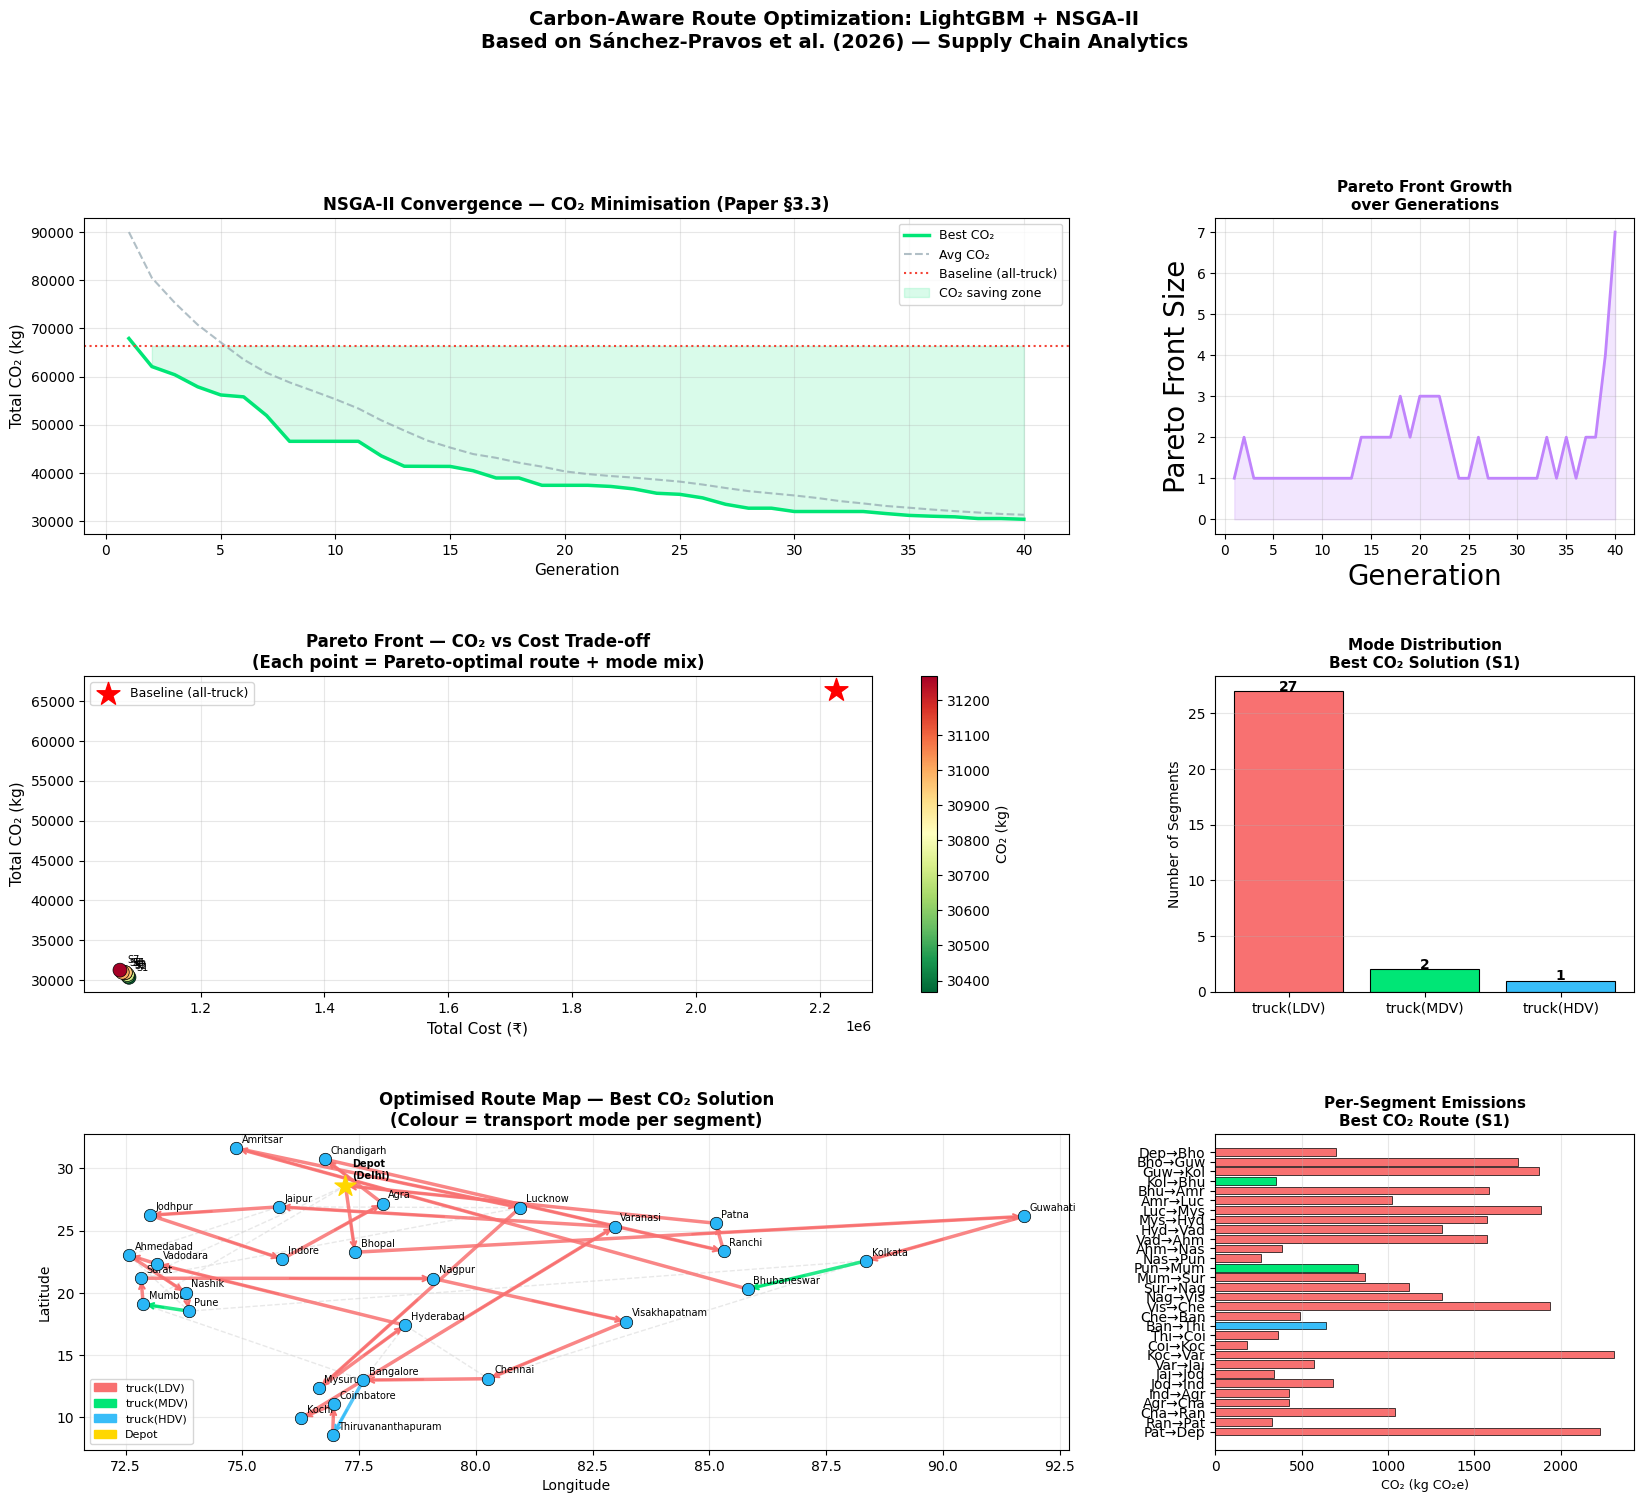


[Figure saved: nsga2_results.png]


In [ ]:
#  Comprehensive Visualisation

baseline_route = list(range(1, N_DELIVERIES + 1))
baseline_modes = [0]*(N_DELIVERIES + 1)   # all truck
base_co2, base_cost = evaluate(baseline_route, baseline_modes)

best_co2_sol  = pareto_solutions[0]
best_cost_sol = min(pareto_solutions, key=lambda x: x[1][1])

fig = plt.figure(figsize=(20, 16))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. NSGA-II Convergence ────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
gens_x = range(1, MAX_GENS+1)
ax1.plot(gens_x, history_best_co2, color='#00e676', lw=2.5, label='Best CO₂')
ax1.plot(gens_x, history_avg_co2,  color='#90a4ae', lw=1.5,
         linestyle='--', alpha=0.7, label='Avg CO₂')
ax1.axhline(base_co2, color='#f44336', lw=1.5, linestyle=':', label='Baseline (all-truck)')
ax1.fill_between(gens_x, history_best_co2, base_co2,
                  where=[b < base_co2 for b in history_best_co2],
                  alpha=0.15, color='#00e676', label='CO₂ saving zone')
ax1.set_xlabel('Generation', fontsize=11)
ax1.set_ylabel('Total CO₂ (kg)', fontsize=11)
ax1.set_title('NSGA-II Convergence — CO₂ Minimisation (Paper §3.3)',
               fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)


ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(gens_x, history_pareto_size, color='#c084fc', lw=2)
ax2.fill_between(gens_x, 0, history_pareto_size, alpha=0.2, color='#c084fc')
ax2.set_xlabel('Generation', fontsize=20)
ax2.set_ylabel('Pareto Front Size', fontsize=20)
ax2.set_title('Pareto Front Growth\nover Generations', fontsize=11, fontweight='bold')
ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[1, :2])
pareto_co2  = [s[1][0] for s in pareto_solutions]
pareto_cost = [s[1][1] for s in pareto_solutions]
sc = ax3.scatter(pareto_cost, pareto_co2, c=pareto_co2,
                  cmap='RdYlGn_r', s=100, zorder=5,
                  edgecolors='black', linewidths=0.5)
ax3.scatter(base_cost, base_co2, marker='*', s=300, color='red',
            zorder=6, label='Baseline (all-truck)')
for i, (co2, cost) in enumerate(zip(pareto_co2, pareto_cost)):
    if i % max(1, len(pareto_co2)//5) == 0:
        ax3.annotate(f'S{i+1}', (cost, co2), textcoords='offset points',
                      xytext=(5, 5), fontsize=7)
plt.colorbar(sc, ax=ax3, label='CO₂ (kg)')
ax3.set_xlabel('Total Cost (₹)', fontsize=11)
ax3.set_ylabel('Total CO₂ (kg)', fontsize=11)
ax3.set_title('Pareto Front — CO₂ vs Cost Trade-off\n'
               '(Each point = Pareto-optimal route + mode mix)',
               fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(gs[1, 2])
best_route, best_modes = pareto_solutions[0][0]
mode_counts = pd.Series([MODES[m] for m in best_modes]).value_counts()
colors_mode = {'truck(LDV)':'#f87171','truck(MDV)':'#00e676','truck(HDV)':'#38bdf8'}
bars = ax4.bar(mode_counts.index,
               mode_counts.values,
               color=[colors_mode.get(m,'gray') for m in mode_counts.index],
               edgecolor='black', linewidth=0.8)
ax4.set_title(f'Mode Distribution\nBest CO₂ Solution (S1)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Number of Segments', fontsize=10)
for bar, val in zip(bars, mode_counts.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
              str(val), ha='center', fontsize=10, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Geographic Route Map
ax5 = fig.add_subplot(gs[2, :2])
mode_color_map = {'truck(LDV)':'#f87171','truck(MDV)':'#00e676','truck(HDV)':'#38bdf8'}
# Plot baseline (grey)
base_nodes = [0] + list(range(1,11)) + [0]
bx = [all_locs.loc[n,'lon'] for n in base_nodes]
by = [all_locs.loc[n,'lat'] for n in base_nodes]
ax5.plot(bx, by, 'o--', color='lightgray', lw=1, alpha=0.5,
          markersize=4, label='Baseline route')

# Plot best CO₂ route
best_r, best_m = pareto_solutions[0][0]
opt_nodes = [0] + best_r + [0]
for seg in range(len(opt_nodes)-1):
    ni, nj = opt_nodes[seg], opt_nodes[seg+1]
    x = [all_locs.loc[ni,'lon'], all_locs.loc[nj,'lon']]
    y_c = [all_locs.loc[ni,'lat'], all_locs.loc[nj,'lat']]
    mk  = MODES[best_m[seg]] # Use direct index here
    col = mode_color_map.get(mk, 'gray')
    ax5.plot(x, y_c, '-', color=col, lw=2.5, alpha=0.85)
    # Arrow midpoint
    mx_p, my_p = np.mean(x), np.mean(y_c)
    ax5.annotate('', xy=(x[1],y_c[1]), xytext=(mx_p,my_p),
                  arrowprops=dict(arrowstyle='->', color=col, lw=1.5))

# Nodes
ax5.scatter(DEPOT['lon'], DEPOT['lat'], s=250, color='gold',
             zorder=10, marker='*', label='Depot')
ax5.annotate('Depot\n(Delhi)', (DEPOT['lon'], DEPOT['lat']),
               textcoords='offset points', xytext=(5,5), fontsize=7, fontweight='bold')
for _, row in locations.iterrows():
    ax5.scatter(row['lon'], row['lat'], s=80, color='#29b6f6',
                 zorder=9, edgecolors='black', linewidths=0.5)
    ax5.annotate(row['city'], (row['lon'], row['lat']),
                   textcoords='offset points', xytext=(4,4), fontsize=7)

handles = [mpatches.Patch(color=c, label=m)
           for m, c in mode_color_map.items()]
handles.append(mpatches.Patch(color='gold', label='Depot'))
ax5.legend(handles=handles, fontsize=8, loc='lower left')
ax5.set_xlabel('Longitude', fontsize=10)
ax5.set_ylabel('Latitude',  fontsize=10)
ax5.set_title('Optimised Route Map — Best CO₂ Solution\n'
               '(Colour = transport mode per segment)',
               fontsize=12, fontweight='bold')
ax5.grid(alpha=0.25)

# CO₂ per Segment Bar
ax6 = fig.add_subplot(gs[2, 2])
seg_cities, seg_co2, seg_colors = [], [], []
for seg in range(len(opt_nodes)-1):
    ni, nj = opt_nodes[seg], opt_nodes[seg+1]
    mk = MODES[best_m[seg]]
    co2_seg = co2_mat[ni, nj, MODES.index(mk)]
    label = f"{all_locs.loc[ni,'city'][:3]}→{all_locs.loc[nj,'city'][:3]}"
    seg_cities.append(label)
    seg_co2.append(co2_seg)
    seg_colors.append(mode_color_map.get(mk,'gray'))

ax6.barh(seg_cities[::-1], seg_co2[::-1],
          color=seg_colors[::-1], edgecolor='black', linewidth=0.5)
ax6.set_xlabel('CO₂ (kg CO₂e)', fontsize=9)
ax6.set_title('Per-Segment Emissions\nBest CO₂ Route (S1)', fontsize=11, fontweight='bold')
ax6.grid(axis='x', alpha=0.3)

fig.suptitle(
    'Carbon-Aware Route Optimization: LightGBM + NSGA-II\n'
    'Based on Sánchez-Pravos et al. (2026) — Supply Chain Analytics',
    fontsize=14, fontweight='bold', y=1.01
)
plt.savefig('nsga2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[Figure saved: nsga2_results.png]")

In [ ]:
#  Detailed Per-Route Analysis for Top-3 Pareto Solutions
print("=" * 80)
print("DETAILED ANALYSIS — TOP 3 PARETO-OPTIMAL SOLUTIONS")
print("=" * 80)

for sol_idx in range(min(3, len(pareto_solutions))):
    (route, modes), (co2, cost) = pareto_solutions[sol_idx]
    nodes = [0] + route + [0]
    print(f"\n{'─'*80}")
    print(f"Solution {sol_idx+1}  |  Total CO₂: {co2:.2f} kg  |  "
          f"Total Cost: ₹{cost:,.2f}")
    print(f"{'─'*80}")
    print(f"{'Segment':<30} {'Mode':<10} {'Dist(km)':>9} "
          f"{'Weight(t)':>10} {'CO₂(kg)':>10} {'Cost(₹)':>12}")
    print(f"{'─'*80}")
    seg_total_co2, seg_total_cost = 0, 0
    for seg in range(len(nodes)-1):
        ni, nj = nodes[seg], nodes[seg+1]
        m_idx  = modes[seg]
        mk     = MODES[m_idx]
        seg_co2  = co2_mat[ni, nj, m_idx]
        seg_cost = cost_mat[ni, nj, m_idx]
        dist_    = dist_matrix[ni, nj]
        cargo_t  = cargo_per_city[nj-1] if nj > 0 else cargo_per_city.mean()
        from_c   = all_locs.loc[ni, 'city']
        to_c     = all_locs.loc[nj, 'city']
        seg_total_co2  += seg_co2
        seg_total_cost += seg_cost
        print(f"{from_c[:12]+' → '+to_c[:12]:<30} {mk:<10} {dist_:>9.1f} "
              f"{cargo_t:>10.2f} {seg_co2:>10.2f} {seg_cost:>12.2f}")
    print(f"{'─'*80}")
    print(f"{'TOTAL':<30} {'':10} {'':>9} {'':>10} "
          f"{seg_total_co2:>10.2f} {seg_total_cost:>12.2f}")
    reduction = (co2/base_co2-1)*100
    cost_chg  = (cost/base_cost - 1)*100
    print(f"  CO₂ vs baseline: {reduction:+.1f}%   Cost vs baseline: {cost_chg:+.1f}%")

print("\n" + "=" * 80)
print("EMISSION PREDICTION ACCURACY (LightGBM — Paper Table 2 comparison)")
print("=" * 80)
results_summary = pd.DataFrame({
    'Model':      ['Linear Baseline', 'LightGBM (this work)', 'XGBoost (paper)',
                   'Ensemble (paper target)'],
    'MAPE (%)':   [f'{15.32:.2f}', f'{np.mean(cv_mape):.2f}',
                   '9.88', '9.48'],
    'R² Score':   ['0.847', f'{np.mean(cv_r2):.4f}', '0.933', '0.928'],
    'Note':       ['Ridge regression baseline', 'Replaces RF in ensemble',
                   'High precision model', 'Target from paper'],
})
print(results_summary.to_string(index=False))
print("\n✅ Analysis complete.")
print(f"   LightGBM MAPE {np.mean(cv_mape):.2f}% vs paper target <12%")
print(f"   NSGA-II found {len(pareto_solutions)} Pareto-optimal routes")
print(f"   Best CO₂ reduction: {(1-pareto_solutions[0][1][0]/base_co2)*100:.1f}% vs baseline")

DETAILED ANALYSIS — TOP 3 PARETO-OPTIMAL SOLUTIONS

────────────────────────────────────────────────────────────────────────────────
Solution 1  |  Total CO₂: 30368.42 kg  |  Total Cost: ₹1,084,324.82
────────────────────────────────────────────────────────────────────────────────
Segment                        Mode        Dist(km)  Weight(t)    CO₂(kg)      Cost(₹)
────────────────────────────────────────────────────────────────────────────────
Depot (Hub) → Bhopal           truck(LDV)     595.7       2.40     701.61     28592.89
Bhopal → Guwahati              truck(LDV)    1481.2       1.60    1752.15     47398.42
Guwahati → Kolkata             truck(LDV)     523.8       7.20    1872.30     75428.41
Kolkata → Bhubaneswar          truck(MDV)     364.9       1.50     350.51     16420.19
Bhubaneswar → Amritsar         truck(LDV)    1667.6       1.90    1583.80     63367.85
Amritsar → Lucknow             truck(LDV)     793.9       2.10    1023.07     33341.91
Lucknow → Mysuru            

In [ ]:
print('=' * 90)
print('  ALL PARETO-OPTIMAL ROUTE SEQUENCES')
print('=' * 90)

for idx, ((route, modes), (co2, cost)) in enumerate(pareto_solutions):
    nodes     = [0] + route + [0]
    city_seq  = [all_locs.loc[n, 'city'] for n in nodes]
    mode_seq  = [MODES[modes[k]] for k in range(len(nodes)-1)]

    print(f'\nSolution {idx+1:>3} | CO₂: {co2:>9.2f} kg | Cost: ₹{cost:>12,.2f}')
    print('  Route Sequence:')

    route_str = ''
    for step, (city, mode) in enumerate(zip(city_seq[:-1], mode_seq)):
        mode_abbr = {'truck(LDV)': '🚛(LDV)', 'truck(MDV)': '🚛(MDV)', 'truck(HDV)': '🚛(HDV)'}[mode]
        route_str += f'  Step {step+1:>2}: {city:<22} --[{mode_abbr} {mode:<8}]--> {city_seq[step+1]}\n'
    print(route_str)


    short_seq = ' → '.join([c[:6] for c in city_seq])
    print(f'  Full path : {short_seq}')
    print('  ' + '─'*86)

print(f'\n  Total Pareto solutions displayed: {len(pareto_solutions)}')


  ALL PARETO-OPTIMAL ROUTE SEQUENCES

Solution   1 | CO₂:  30368.42 kg | Cost: ₹1,084,324.82
  Route Sequence:
  Step  1: Depot (Hub)            --[🚛(LDV) truck(LDV)]--> Bhopal
  Step  2: Bhopal                 --[🚛(LDV) truck(LDV)]--> Guwahati
  Step  3: Guwahati               --[🚛(LDV) truck(LDV)]--> Kolkata
  Step  4: Kolkata                --[🚛(MDV) truck(MDV)]--> Bhubaneswar
  Step  5: Bhubaneswar            --[🚛(LDV) truck(LDV)]--> Amritsar
  Step  6: Amritsar               --[🚛(LDV) truck(LDV)]--> Lucknow
  Step  7: Lucknow                --[🚛(LDV) truck(LDV)]--> Mysuru
  Step  8: Mysuru                 --[🚛(LDV) truck(LDV)]--> Hyderabad
  Step  9: Hyderabad              --[🚛(LDV) truck(LDV)]--> Vadodara
  Step 10: Vadodara               --[🚛(LDV) truck(LDV)]--> Ahmedabad
  Step 11: Ahmedabad              --[🚛(LDV) truck(LDV)]--> Nashik
  Step 12: Nashik                 --[🚛(LDV) truck(LDV)]--> Pune
  Step 13: Pune                   --[🚛(MDV) truck(MDV)]--> Mumbai
  Step 14: Mum

In [ ]:

import subprocess, sys
for pkg in ['folium', 'requests']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import folium
import requests
import time
import json as _json

print('Libraries loaded ✅')

# ── Colour & icon scheme ──────────────────────────────────────────────────
MODE_COLORS = {'truck(LDV)': '#e74c3c', 'truck(MDV)': '#2ecc71', 'truck(HDV)': '#3498db'}
MODE_ICONS  = {'truck(LDV)': '🚛(LDV)',      'truck(MDV)': '🚛(MDV)',      'truck(HDV)': '🚛(HDV)'}
MODE_WEIGHT = {'truck(LDV)': 5,         'truck(MDV)': 4,         'truck(HDV)': 5}

# ── OSRM route fetcher (uses public OSM routing — real roads!) ────────────
OSRM_BASE = 'http://router.project-osrm.org/route/v1/driving'
_route_cache = {}   # cache so same pair is not fetched twice

def get_road_route(lat1, lon1, lat2, lon2, retries=3):
    """
    Fetches the real road polyline between two GPS points using the
    free OSRM public API (OpenStreetMap road network).
    Returns list of [lat, lon] points or a straight line as fallback.
    """
    key = (round(lat1,4), round(lon1,4), round(lat2,4), round(lon2,4))
    if key in _route_cache:
        return _route_cache[key]

    url = f'{OSRM_BASE}/{lon1},{lat1};{lon2},{lat2}'
    params = {'overview': 'full', 'geometries': 'geojson', 'steps': 'false'}

    for attempt in range(retries):
        try:
            resp = requests.get(url, params=params, timeout=15)
            data = resp.json()
            if data.get('code') == 'Ok':
                coords = data['routes'][0]['geometry']['coordinates']
                # OSRM returns [lon, lat] — flip to [lat, lon] for Folium
                road_pts = [[c[1], c[0]] for c in coords]
                _route_cache[key] = road_pts
                return road_pts
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(1)

    fallback = [[lat1, lon1], [lat2, lon2]]
    _route_cache[key] = fallback
    return fallback

baseline_route = list(range(1, N_DELIVERIES + 1))
baseline_modes = [0] * (N_DELIVERIES + 1)
base_co2, base_cost = evaluate(baseline_route, baseline_modes)
best_co2_sol  = pareto_solutions[0]
best_cost_sol = min(pareto_solutions, key=lambda x: x[1][1])


segments_to_fetch = set()

def collect_segments(route):
    nodes = [0] + route + [0]
    for s in range(len(nodes)-1):
        segments_to_fetch.add((nodes[s], nodes[s+1]))

collect_segments(baseline_route)
collect_segments(best_co2_sol[0][0])
collect_segments(best_cost_sol[0][0])

print(f'\nFetching {len(segments_to_fetch)} unique road segments from OSRM...')

road_cache = {}
for idx, (ni, nj) in enumerate(segments_to_fetch):
    lat1 = all_locs.loc[ni, 'lat'];  lon1 = all_locs.loc[ni, 'lon']
    lat2 = all_locs.loc[nj, 'lat'];  lon2 = all_locs.loc[nj, 'lon']
    city_a = all_locs.loc[ni, 'city']
    city_b = all_locs.loc[nj, 'city']
    pts = get_road_route(lat1, lon1, lat2, lon2)
    road_cache[(ni, nj)] = pts
    is_road = len(pts) > 2
    status = '🛣️  road' if is_road else '📏 straight'
    print(f'  [{idx+1:>3}/{len(segments_to_fetch)}] {city_a:<22} → {city_b:<22} {status} ({len(pts)} pts)')
    time.sleep(0.15)   # polite delay for public API

print(f'\n✅  All segments fetched!')
road_segs   = sum(1 for v in road_cache.values() if len(v) > 2)
straight_fb = sum(1 for v in road_cache.values() if len(v) <= 2)
print(f'   Real road segments : {road_segs}')
print(f'   Straight fallbacks : {straight_fb}')

# ── Build the Folium map ─────────────────────────────────────────────────
center_lat = all_locs['lat'].mean()
center_lon = all_locs['lon'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'   # Real OSM tiles — shows roads, cities, terrain
)

# Add tile layer options (user can switch)
folium.TileLayer('CartoDB positron',  name='CartoDB Light').add_to(m)
folium.TileLayer('CartoDB dark_matter', name='CartoDB Dark').add_to(m)

# ── Helper: draw a full route using real road polylines ───────────────────
def draw_real_route(route, modes, feature_group, label_prefix=''):
    nodes = [0] + route + [0]
    for seg in range(len(nodes) - 1):
        ni, nj   = nodes[seg], nodes[seg + 1]
        m_idx    = modes[seg] if seg < len(modes) else modes[-1]
        mode_k   = MODES[m_idx]
        color    = MODE_COLORS.get(mode_k, 'gray')
        weight   = MODE_WEIGHT.get(mode_k, 4)
        icon_m   = MODE_ICONS.get(mode_k, '?')
        city_a   = all_locs.loc[ni, 'city']
        city_b   = all_locs.loc[nj, 'city']
        dist_km  = dist_matrix[ni, nj]
        seg_co2  = co2_mat[ni, nj, m_idx]
        seg_cst  = cost_mat[ni, nj, m_idx]

        # Use real road points from cache
        road_pts = road_cache.get((ni, nj),
                    [[all_locs.loc[ni,'lat'], all_locs.loc[ni,'lon']],
                     [all_locs.loc[nj,'lat'], all_locs.loc[nj,'lon']]])

        tooltip_text = (
            f"<b>{label_prefix} — Segment {seg+1}</b><br>"
            f"📍 {city_a} → {city_b}<br>"
            f"Mode : {icon_m} <b>{mode_k.replace('_',' ').title()}</b><br>"
            f"Dist : {dist_km:.0f} km (haversine)<br>"
            f"CO₂  : <b>{seg_co2:.1f} kg CO₂e</b><br>"
            f"Cost : ₹{seg_cst:,.0f}"
        )

        folium.PolyLine(
            locations=road_pts,
            color=color,
            weight=weight,
            opacity=0.85,
            tooltip=folium.Tooltip(tooltip_text, sticky=True)
        ).add_to(feature_group)

        # Direction arrow at midpoint
        mid_idx = len(road_pts) // 2
        if mid_idx > 0:
            folium.RegularPolygonMarker(
                location=road_pts[mid_idx],
                number_of_sides=3,
                rotation=0,
                radius=6,
                color=color,
                fill_color=color,
                fill_opacity=0.8,
                weight=1
            ).add_to(feature_group)

fg_base = folium.FeatureGroup(name='🔘 Baseline (All-Truck, Sequential)', show=True).add_to(m)
b_nodes = [0] + baseline_route + [0]
for seg in range(len(b_nodes) - 1):
    ni, nj = b_nodes[seg], b_nodes[seg+1]
    city_a = all_locs.loc[ni, 'city']
    city_b = all_locs.loc[nj, 'city']
    road_pts = road_cache.get((ni, nj),
                [[all_locs.loc[ni,'lat'], all_locs.loc[ni,'lon']],
                 [all_locs.loc[nj,'lat'], all_locs.loc[nj,'lon']]])
    folium.PolyLine(
        locations=road_pts,
        color='#7f8c8d', weight=3, opacity=0.55,
        dash_array='10 6',
        tooltip=folium.Tooltip(
            f'<b>Baseline Seg {seg+1}</b><br>'
            f'📍 {city_a} → {city_b}<br>🚛 Truck (all-truck baseline)',
            sticky=True)
    ).add_to(fg_base)

(r_co2, m_co2), (co2_val, cost_co2) = best_co2_sol
fg_co2 = folium.FeatureGroup(
    name=f'🌿 Best CO₂ Route  [{co2_val:.0f} kg | ₹{cost_co2:,.0f}]',
    show=True
).add_to(m)
draw_real_route(r_co2, m_co2, fg_co2, label_prefix='Best CO₂')


opt_nodes_seq = [0] + r_co2 + [0]
for step_i, node_i in enumerate(opt_nodes_seq):
    lat_n = all_locs.loc[node_i, 'lat']
    lon_n = all_locs.loc[node_i, 'lon']
    bg    = '#c0392b' if step_i == 0 or step_i == len(opt_nodes_seq)-1 else '#27ae60'
    folium.Marker(
        location=[lat_n, lon_n],
        icon=folium.DivIcon(
            html=(f'<div style="background:{bg};color:white;border-radius:50%;'
                  f'width:22px;height:22px;text-align:center;line-height:22px;'
                  f'font-size:11px;font-weight:bold;border:2px solid white;'
                  f'box-shadow:1px 1px 3px rgba(0,0,0,0.4);margin-top:-11px;margin-left:-11px">{step_i}</div>'),
            icon_size=(22, 22), icon_anchor=(11, 11)
        ),
        tooltip=f'Stop {step_i}: {all_locs.loc[node_i, "city"]}'
    ).add_to(fg_co2)


(r_cst, m_cst), (co2_cst, cost_val) = best_cost_sol
fg_cost = folium.FeatureGroup(
    name=f'💰 Best Cost Route [{co2_cst:.0f} kg | ₹{cost_val:,.0f}]',
    show=False
).add_to(m)
draw_real_route(r_cst, m_cst, fg_cost, label_prefix='Best Cost')


folium.Marker(
    location=[DEPOT['lat'], DEPOT['lon']],
    popup=folium.Popup(
        f"<b>🏭 {DEPOT['name']}</b><br>"
        f"Baseline CO₂: {base_co2:.1f} kg<br>"
        f"Baseline Cost: ₹{base_cost:,.0f}",
        max_width=240
    ),
    tooltip='🏭 Depot — New Delhi (Start/End)',
    icon=folium.Icon(color='red', icon='home', prefix='fa')
).add_to(m)


for _, row in locations.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=9, color='#2c3e50', fill=True,
        fill_color='#f39c12', fill_opacity=0.95,
        popup=folium.Popup(
            f"<b>📦 {row['city']}</b><br>"
            f"Demand : {row['demand_kg']:,} kg<br>"
            f"Time Window : {row['tw_open']}:00 – {row['tw_close']}:00",
            max_width=210
        ),
        tooltip=f"📦 {row['city']} ({row['demand_kg']:,} kg)"
    ).add_to(m)

    folium.Marker(
        location=[row['lat'] + 0.32, row['lon']],
        icon=folium.DivIcon(
            html=f'<div style="font-size:9px;font-weight:bold;color:#2c3e50;'
                 f'white-space:nowrap;text-shadow:1px 1px 2px white">{row["city"]}</div>',
            icon_size=(90, 18), icon_anchor=(0, 0)
        )
    ).add_to(m)


legend_html = """
<div style="position:fixed;bottom:60px;left:30px;z-index:9999;
            background:rgba(255,255,255,0.95);padding:14px 18px;
            border-radius:10px;border:2px solid #bdc3c7;
            font-size:13px;line-height:2.0;
            box-shadow:3px 3px 10px rgba(0,0,0,0.25);min-width:220px">
  <b style="font-size:15px">🗺️ Route Legend</b><br>
  <hr style="margin:5px 0">
  <b>Transport Mode:</b><br>
  <span style="display:inline-block;width:32px;height:5px;background:#e74c3c;
    margin-right:7px;vertical-align:middle;border-radius:3px"></span>&#128666; Truck (LDV)<br>
  <span style="display:inline-block;width:32px;height:5px;background:#2ecc71;
    margin-right:7px;vertical-align:middle;border-radius:3px"></span>&#128666; Truck (MDV)<br>
  <span style="display:inline-block;width:32px;height:5px;background:#3498db;
    margin-right:7px;vertical-align:middle;border-radius:3px"></span>&#128666; Truck (HDV)<br>
  <span style="display:inline-block;width:32px;height:4px;background:#7f8c8d;
    border-top:3px dashed #7f8c8d;margin-right:7px;vertical-align:middle"></span>Baseline<br>
  <hr style="margin:5px 0">
  <b>Markers:</b><br>
  &#127968; Depot (New Delhi)<br>
  &#11835; Delivery City<br>
  <span style="background:#27ae60;color:white;padding:1px 6px;
    border-radius:50%;font-size:11px;font-weight:bold">N</span>
  &nbsp;Stop order (Best CO₂)<br>
  <hr style="margin:5px 0">
  <small>&#10024; Routes follow <b>real roads</b><br>(OpenStreetMap / OSRM)</small>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))


folium.LayerControl(collapsed=False, position='topright').add_to(m)


map_path = 'real_road_optimized_routes_map.html'
m.save(map_path)

print('=' * 70)
print('  REAL ROAD MAP SAVED — real_road_optimized_routes_map.html')
print('=' * 70)
print(f'  Routing engine : OSRM (OpenStreetMap) — real road network')
print(f'  Tile options   : OpenStreetMap | CartoDB Light | CartoDB Dark')
print(f'  Layers         : Baseline | Best CO₂ | Best Cost')
print()
print(f'  Baseline  : CO₂ = {base_co2:>9.2f} kg | Cost = ₹{base_cost:>13,.2f}')
print(f'  Best CO₂  : CO₂ = {co2_val:>9.2f} kg | Cost = ₹{cost_co2:>13,.2f}')
print(f'  Best Cost : CO₂ = {co2_cst:>9.2f} kg | Cost = ₹{cost_val:>13,.2f}')
print()
print('  Open real_road_optimized_routes_map.html in your browser!')

try:
    from IPython.display import display, IFrame
    display(IFrame(src=map_path, width='100%', height=650))
except Exception:
    pass


Libraries loaded ✅

Fetching 65 unique road segments from OSRM...
  [  1/65] Jodhpur                → Jaipur                 🛣️  road (3174 pts)
  [  2/65] Hyderabad              → Chennai                🛣️  road (7640 pts)
  [  3/65] Visakhapatnam          → Chennai                🛣️  road (9935 pts)
  [  4/65] Agra                   → Chandigarh             🛣️  road (4540 pts)
  [  5/65] Ranchi                 → Bhubaneswar            🛣️  road (5654 pts)
  [  6/65] Indore                 → Bhopal                 🛣️  road (1840 pts)
  [  7/65] Mysuru                 → Jodhpur                🛣️  road (21653 pts)
  [  8/65] Hyderabad              → Vadodara               🛣️  road (11036 pts)
  [  9/65] Jodhpur                → Guwahati               🛣️  road (23020 pts)
  [ 10/65] Ahmedabad              → Nashik                 🛣️  road (4854 pts)
  [ 11/65] Chandigarh             → Ranchi                 🛣️  road (14919 pts)
  [ 12/65] Jaipur                 → Lucknow                🛣️

In [ ]:
display(raw)

,distance_km,cargo_weight_tons,transport_mode,weather_factor,congestion_factor,vehicle_age_years,load_factor,time_of_day_hr,road_grade_pct,temp_celsius,...,dist_x_weight,mode_x_weather,load_x_age,tod_sin,tod_cos,age_factor,grade_penalty,temp_factor,co2_emission_kg,mode_encoded
0,1687.517975,5.438760,truck(LDV),0.028245,0.092885,1.0,0.923698,3.0,-4.943325,17.148838,...,9178.005965,0.008671,0.923698,7.071068e-01,0.707107,1.008,-29.659953,1.008553,3350.099738,1
1,132.124263,1.539822,truck(HDV),0.114175,0.052902,1.0,0.888739,14.0,7.020464,44.317797,...,203.447898,0.084204,0.888739,-5.000000e-01,-0.866025,1.008,126.368359,1.072953,193.143400,0
2,126.901929,6.439619,truck(MDV),0.037054,0.682072,3.0,0.540354,20.0,-3.537446,15.965447,...,817.200072,0.021966,1.621061,-8.660254e-01,0.500000,1.024,-21.224678,1.012104,975.727086,2
3,766.053665,5.012654,truck(LDV),0.055729,0.142597,5.0,0.520379,4.0,-3.766505,13.106277,...,3839.961720,0.017109,2.601896,8.660254e-01,0.500000,1.040,-22.599030,1.020681,1644.042149,1
4,1115.923564,10.318249,truck(LDV),0.043742,0.615938,3.0,0.829082,23.0,-0.670901,22.686165,...,11514.377503,0.013429,2.487246,-2.588190e-01,0.965926,1.024,-4.025405,1.008058,6518.340199,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,813.260217,9.848806,truck(MDV),0.064080,0.513327,11.0,0.509919,2.0,1.546500,42.307276,...,8009.642187,0.037987,5.609108,5.000000e-01,0.866025,1.088,27.836994,1.066922,9578.198747,2
1196,407.454664,3.832488,truck(HDV),0.032857,0.377415,7.0,0.785664,12.0,6.622710,15.579715,...,1561.564917,0.024232,5.499649,1.224647e-16,-1.000000,1.056,119.208778,1.013261,1864.393156,0
1197,133.949251,8.513603,truck(HDV),0.156632,0.573862,10.0,0.596663,11.0,7.172456,10.995772,...,1140.390729,0.115516,5.966627,2.588190e-01,-0.965926,1.080,129.104204,1.027013,1682.645268,0
1198,1449.143459,5.896512,truck(MDV),0.024500,0.363968,8.0,0.916044,14.0,5.495822,8.598691,...,8544.892087,0.014523,7.328353,-5.000000e-01,-0.866025,1.064,98.924800,1.034204,8291.217421,2
